Device: cuda | GPU: NVIDIA GeForce RTX 5090

 LOADING BASELINE COHORTS: T1 Characterization (Benign vs Malignant)

 LOADING BASELINE COHORTS: T2 Detection (Malignant vs Normal+Benign)

 LOADING BASELINE COHORTS: T3 Screening (Malignant vs Normal)

T1 Characterization (Benign vs Malignant)
  Model                      OOF-AUC  Mean Fold-AUC           95% CI       Sens   Spec   Sig 
  ------------------------------------------------------------------------------------------------
  MammoXV                    0.8036   0.8052 (±0.0353)    [0.771-0.836]   0.659  0.822   ---  <
  ConvNeXt-Base              0.7764   0.7975 (±0.0207)    [0.742-0.812]   0.621  0.848   ns  
  ViT-B16                    0.7459   0.7740 (±0.0233)    [0.708-0.783]   0.638  0.768   **  
  SwinV2-B                   0.6938   0.7139 (±0.0563)    [0.652-0.732]   0.480  0.818   *** 
  EfficientNet-B4            0.6825   0.6855 (±0.0432)    [0.643-0.721]   0.542  0.741   *** 
  ResNet50-DualConcat        0.6629   0.6599 

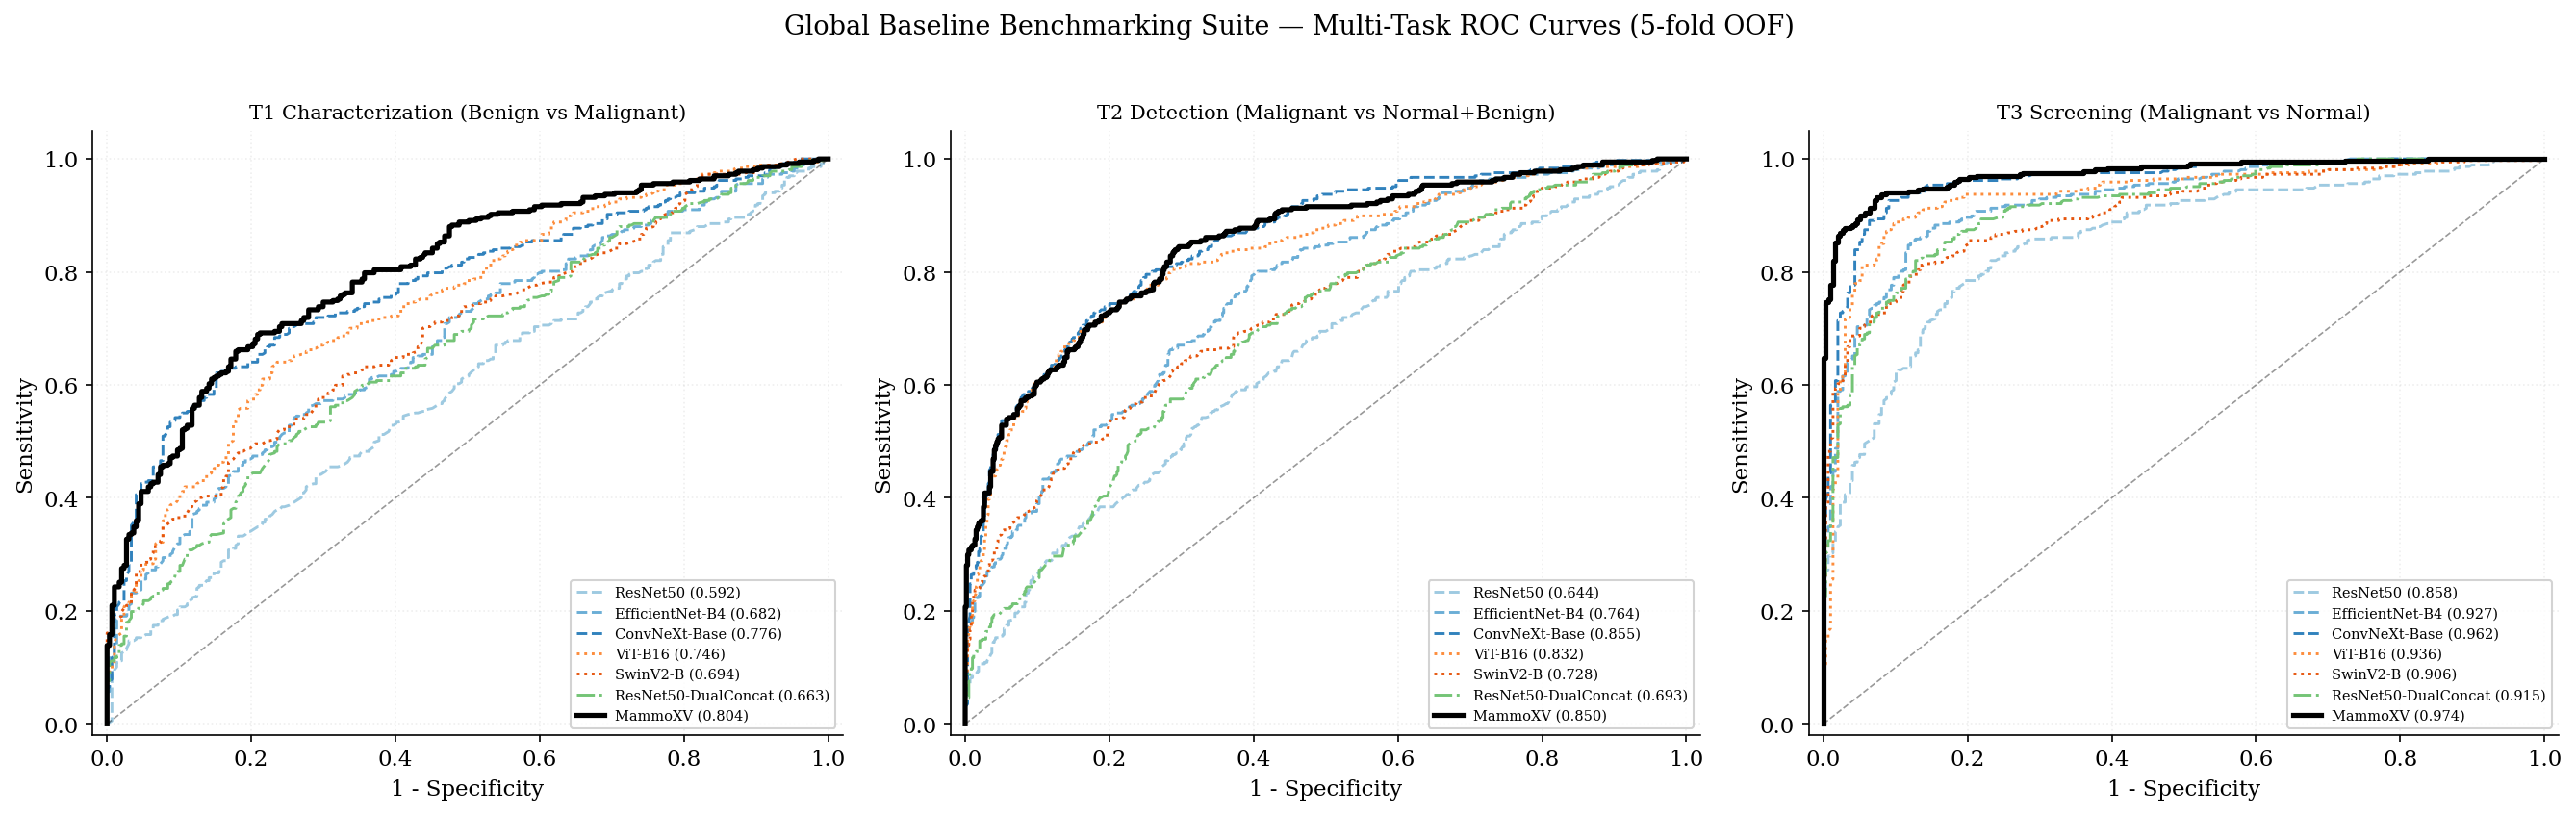

In [11]:
# =====================================================================
# Dual-View Mammography Deep Learning Framework
# 06_baselines.ipynb — Peer-Review Baseline Benchmark Suite
#
# Core Focus: Load checkpoints/predictions dynamically if exists, bypassing 
# training loops. Executes strict structural baseline training if assets are missing.
# Standardizes all evaluations under identical fair 448 matrix layout.
# =====================================================================

import os
import random
import warnings
import cv2
from collections import OrderedDict
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import scipy.stats as _stats
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False
})

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# ─── 1. GLOBAL PATHS & CONFIGURATIONS ────────────────────────────────
SPLIT_CSV    = './splits/patient_folds.csv'
IMAGE_DIR    = './processed'  
CKPT_DIR     = './checkpoints/baselines_production_448'
MAMMOXV_DIR  = './checkpoints/all_tasks'
FIG_DIR      = './outputs/figures'
STAT_DIR     = './outputs/statistics'

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(STAT_DIR, exist_ok=True)

# Standardized publication hyperparameters
IMG_SIZE = 448  
LR = 1e-4
BACKBONE_LR_MULT = 0.1
WEIGHT_DECAY = 1e-2
NUM_EPOCHS = 50
WARMUP_EPOCHS = 3
ES_START = 8
PATIENCE = 12
BATCH_SIZE = 16
DROPOUT = 0.3
FOCAL_ALPHA = 0.5
FOCAL_GAMMA = 2.0
N_WORKERS = 4
N_FOLDS = 5
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Load and prepare target benchmark cohorts
df_all = pd.read_csv(SPLIT_CSV)
if 'label_char' not in df_all.columns:
    df_all['label_char'] = df_all.apply(lambda r: 1 if r['class_3']=='Malign' else (0 if r['class_3']=='Benign' else -1), axis=1)
if 'label_det' not in df_all.columns:
    df_all['label_det'] = (df_all['class_3'] == 'Malign').astype(int)
if 'label_screen' not in df_all.columns:
    df_all['label_screen'] = df_all.apply(lambda r: 1 if r['class_3']=='Malign' else (0 if r['class_3']=='Normal' else -1), axis=1)

TASK_CONFIGS = [
    {'name': 'T1_Char',   'label_col': 'label_char',   'filter': lambda df: df[df['label_char']   != -1].copy(), 'desc': 'T1 Characterization (Benign vs Malignant)'},
    {'name': 'T2_Det',    'label_col': 'label_det',    'filter': lambda df: df.copy(),                            'desc': 'T2 Detection (Malignant vs Normal+Benign)'},
    {'name': 'T3_Screen', 'label_col': 'label_screen', 'filter': lambda df: df[df['label_screen'] != -1].copy(), 'desc': 'T3 Screening (Malignant vs Normal)'},
]

BASELINE_REGISTRY = OrderedDict([
    ('ResNet50',            {'timm_name': 'resnet50.a1_in1k',                          'img_size': IMG_SIZE, 'dual_view': False}),
    ('EfficientNet-B4',     {'timm_name': 'efficientnet_b4.ra2_in1k',                  'img_size': IMG_SIZE, 'dual_view': False}),
    ('ConvNeXt-Base',       {'timm_name': 'convnext_base.fb_in22k_ft_in1k',            'img_size': IMG_SIZE, 'dual_view': False}),
    ('ViT-B16',             {'timm_name': 'vit_base_patch16_384.augreg_in21k_ft_in1k', 'img_size': IMG_SIZE, 'dual_view': False}),
    ('SwinV2-B',            {'timm_name': 'swinv2_base_window12to16_192to256.ms_in22k_ft_in1k', 'img_size': IMG_SIZE, 'dual_view': False}),
    ('ResNet50-DualConcat', {'timm_name': 'resnet50.a1_in1k',                          'img_size': IMG_SIZE, 'dual_view': True}),
])

MAMMOXV = 'MammoXV'

# ─── 2. STABLE REPRODUCIBLE DATASET LAYER ───────────────────────────
def make_tfm(img_size, train=True):
    if train:
        return A.Compose([
            A.Resize(img_size, img_size, interpolation=cv2.INTER_AREA), 
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=10, border_mode=0, p=0.5),
            A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
            A.Normalize(mean=MEAN, std=STD), 
            ToTensorV2()
        ])
    return A.Compose([
        A.Resize(img_size, img_size, interpolation=cv2.INTER_AREA), 
        A.Normalize(mean=MEAN, std=STD), 
        ToTensorV2()
    ])

class SingleViewDataset(Dataset):
    def __init__(self, df, img_size, label_col, train=True):
        self.paths = df['cc_path'].values
        self.labels = df[label_col].astype(float).values
        self.tfm = make_tfm(img_size, train)
    def __len__(self): return len(self.paths)
    def _load(self, p):
        full_path = os.path.join(IMAGE_DIR, p)
        img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
        if img is None: raise FileNotFoundError(f"Missing slice: {full_path}")
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    def __getitem__(self, i):
        return self.tfm(image=self._load(self.paths[i]))['image'], torch.tensor(self.labels[i], dtype=torch.float32)

class DualViewDataset(Dataset):
    def __init__(self, df, img_size, label_col, train=True):
        self.cc = df['cc_path'].values
        self.mlo = df['mlo_path'].values
        self.labels = df[label_col].astype(float).values
        self.tfm = make_tfm(img_size, train)
    def __len__(self): return len(self.cc)
    def _load(self, p):
        full_path = os.path.join(IMAGE_DIR, p)
        img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
        if img is None: raise FileNotFoundError(f"Missing slice: {full_path}")
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    def __getitem__(self, i):
        cc = self.tfm(image=self._load(self.cc[i]))['image']
        mlo = self.tfm(image=self._load(self.mlo[i]))['image']
        return cc, mlo, torch.tensor(self.labels[i], dtype=torch.float32)

# ─── 3. BASELINE ARCHITECTURES & LOSS CRITERION ──────────────────────
def _load_backbone(timm_name):
    try:
        if 'swin' in timm_name.lower():
            m = timm.create_model(timm_name, pretrained=True, num_classes=0, global_pool='avg', 
                                  img_size=IMG_SIZE, strict_img_size=False)
        else:
            m = timm.create_model(timm_name, pretrained=True, num_classes=0, global_pool='avg', img_size=IMG_SIZE)
        return m, m.num_features
    except TypeError:
        m = timm.create_model(timm_name, pretrained=True, num_classes=0, global_pool='avg')
        return m, m.num_features

class SingleViewBaseline(nn.Module):
    def __init__(self, timm_name):
        super().__init__()
        self.backbone, fd = _load_backbone(timm_name)
        self.head = nn.Sequential(nn.LayerNorm(fd), nn.Dropout(DROPOUT), nn.Linear(fd, 1))
    def forward(self, x): return self.head(self.backbone(x)).squeeze(-1)

class DualViewConcatBaseline(nn.Module):
    def __init__(self, timm_name):
        super().__init__()
        self.bb_cc, fd = _load_backbone(timm_name)
        self.bb_mlo, _ = _load_backbone(timm_name)
        self.head = nn.Sequential(
            nn.LayerNorm(fd * 2), nn.Dropout(DROPOUT),
            nn.Linear(fd * 2, 512), nn.GELU(), nn.Dropout(DROPOUT), nn.Linear(512, 1)
        )
    def forward(self, cc, mlo): return self.head(torch.cat([self.bb_cc(cc), self.bb_mlo(mlo)], dim=-1)).squeeze(-1)

def build_model(cfg):
    if cfg['dual_view']: return DualViewConcatBaseline(cfg['timm_name']).to(DEVICE)
    return SingleViewBaseline(cfg['timm_name']).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        return (FOCAL_ALPHA * (1 - pt)**FOCAL_GAMMA * bce).mean()

focal_criterion = FocalLoss()

def compute_metrics(y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    t = thr[np.argmax(tpr - fpr)]
    preds = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {'auc': auc, 'sens': tp / (tp + fn + 1e-8), 'spec': tn / (tn + fp + 1e-8)}

# ─── 4. BASELINE EXECUTION MOTOR (INFERENCE OR TRAINING FALLBACK) ────
def run_baseline_fold(df_task, label_col, cfg, bl_name, task_name, fold_k):
    dv = cfg['dual_view']
    DS = DualViewDataset if dv else SingleViewDataset
    sz = cfg['img_size']
    df_ote = df_task[df_task['fold'] == fold_k].copy()
    dl_te = DataLoader(DS(df_ote, sz, label_col, False), batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=N_WORKERS, pin_memory=True)
    
    ckpt = os.path.join(CKPT_DIR, f"{task_name}_{bl_name}_fold{fold_k}.pt")
    
    if os.path.exists(ckpt):
        model = build_model(cfg)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        model.eval()
        op, ol = [], []
        with torch.no_grad():
            for batch in dl_te:
                if dv:
                    cc_in, mlo_in, lbl = [b.to(DEVICE) for b in batch]
                    with autocast(): logits = model(cc_in, mlo_in)
                else:
                    imgs, lbl = batch[0].to(DEVICE), batch[1].to(DEVICE)
                    with autocast(): logits = model(imgs)
                op.extend(torch.nan_to_num(torch.sigmoid(logits), nan=0.5).float().cpu().numpy())
                ol.extend(lbl.cpu().numpy())
        return df_ote['patient_id'].values, np.array(ol), np.array(op)
        
    print(f"    [WARN] Checkpoint missing! Training baseline architecture: {bl_name} Fold {fold_k}")
    df_otr = df_task[df_task['fold'] != fold_k].copy()
    ivf = [f for f in range(N_FOLDS) if f != fold_k][-1]
    df_itr = df_otr[df_otr['fold'] != ivf].copy()
    df_iva = df_otr[df_otr['fold'] == ivf].copy()

    ltr = df_itr[label_col].values.astype(int)
    cc = np.bincount(ltr)
    w = 1.0 / cc[ltr]
    smp = WeightedRandomSampler(w, len(w), replacement=True)

    kw = dict(num_workers=N_WORKERS, pin_memory=True)
    dl_tr = DataLoader(DS(df_itr, sz, label_col, True),  batch_size=BATCH_SIZE,   sampler=smp,    **kw)
    dl_va = DataLoader(DS(df_iva, sz, label_col, False), batch_size=BATCH_SIZE * 2, shuffle=False,  **kw)

    model = build_model(cfg)
    bb_p, hd_p = [], []
    for pn, p in model.named_parameters(): (hd_p if 'head' in pn else bb_p).append(p)
        
    opt = torch.optim.AdamW([{'params': bb_p, 'lr': LR * BACKBONE_LR_MULT}, {'params': hd_p, 'lr': LR}], weight_decay=WEIGHT_DECAY)
    scaler = GradScaler()
    best = 0.0

    for ep in range(1, NUM_EPOCHS + 1):
        frozen = ep <= WARMUP_EPOCHS
        for p in bb_p: p.requires_grad_(not frozen)
        model.train()
        for batch in dl_tr:
            opt.zero_grad()
            if dv:
                cc_in, mlo_in, lbl = [b.to(DEVICE) for b in batch]
                with autocast(): logits = model(cc_in, mlo_in)
            else:
                imgs, lbl = batch[0].to(DEVICE), batch[1].to(DEVICE)
                with autocast(): logits = model(imgs)
            logits = torch.nan_to_num(logits, nan=0.0)
            loss = focal_criterion(logits, lbl)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            
        model.eval(); vp, vl = [], []
        with torch.no_grad():
            for batch in dl_va:
                if dv:
                    cc_in, mlo_in, lbl = [b.to(DEVICE) for b in batch]
                    with autocast(): logits = model(cc_in, mlo_in)
                else:
                    imgs, lbl = batch[0].to(DEVICE), batch[1].to(DEVICE)
                    with autocast(): logits = model(imgs)
                vp.extend(torch.nan_to_num(torch.sigmoid(logits), nan=0.5).float().cpu().numpy())
                vl.extend(lbl.cpu().numpy())

        vp, vl = np.array(vp), np.array(vl)
        ok = np.isfinite(vp)
        val_auc = roc_auc_score(vl[ok], vp[ok]) if ok.sum() >= 2 and len(np.unique(vl[ok])) > 1 else 0.0
        if val_auc > best:
            best = val_auc; torch.save(model.state_dict(), ckpt)
        if ep >= ES_START and ep >= PATIENCE: break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval(); op, ol = [], []
    with torch.no_grad():
        for batch in dl_te:
            if dv:
                cc_in, mlo_in, lbl = [b.to(DEVICE) for b in batch]
                with autocast(): logits = model(cc_in, mlo_in)
            else:
                imgs, lbl = batch[0].to(DEVICE), batch[1].to(DEVICE)
                with autocast(): logits = model(imgs)
            op.extend(torch.nan_to_num(torch.sigmoid(logits), nan=0.5).float().cpu().numpy())
            ol.extend(lbl.cpu().numpy())
    del model; torch.cuda.empty_cache()
    return df_ote['patient_id'].values, np.array(ol), np.array(op)

# ─── 5. ANALYSIS ENGINE AND HYPOTHESIS TESTING MATRICES ──────────────
def _sc(yt, ys):
    pos, neg = ys[yt == 1], ys[yt == 0]
    return np.array([(neg < p).mean() + 0.5 * (neg == p).mean() for p in pos]), np.array([(pos > n).mean() + 0.5 * (pos == n).mean() for n in neg])

def delong_test(yt, pa, pb):
    a01, a10 = _sc(yt, pa); b01, b10 = _sc(yt, pb); aa, ab = a10.mean(), b10.mean()
    cov = (np.cov(np.stack([a10 - aa, b10 - ab]), ddof=1) / len(a10) + np.cov(np.stack([a01 - aa, b01 - ab]), ddof=1) / len(a01))
    return 2 * (1 - _stats.norm.cdf(abs((aa - ab) / np.sqrt(cov[0, 0] + cov[1, 1] - 2 * cov[0, 1] + 1e-12))))

def bci(yt, yp, n=1000):
    rng = np.random.default_rng(SEED); aucs = []
    for _ in range(n):
        idx = rng.integers(0, len(yt), len(yt))
        if len(np.unique(yt[idx])) < 2: continue
        aucs.append(roc_auc_score(yt[idx], yp[idx]))
    return np.percentile(aucs, [2.5, 97.5])

def sig(p):
    if np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

if __name__ == "__main__":
    ALL_OOF = {}
    FOLD_SCORES = {} # Dynamic registry for tracking cross-validation loops
    
    for tc in TASK_CONFIGS:
        df_task = tc['filter'](df_all).reset_index(drop=True)
        name = tc['name']; label_col = tc['label_col']
        print(f"\n LOADING BASELINE COHORTS: {tc['desc']}")
        
        for bl_name, cfg in BASELINE_REGISTRY.items():
            oof_csv = os.path.join(CKPT_DIR, f"{name}_{bl_name}_oof.csv")
            if os.path.exists(oof_csv):
                ALL_OOF[(name, bl_name)] = pd.read_csv(oof_csv)
                # Compute fold metrics from cached loops safely
                f_scores = []
                for k in range(N_FOLDS):
                    df_f = df_task[df_task['fold'] == k]
                    pids_f = df_f['patient_id'].values
                    m_df = ALL_OOF[(name, bl_name)]
                    m_f = m_df[m_df['patient_id'].isin(pids_f)]
                    if len(m_f) > 0 and len(np.unique(m_f['label'].values)) > 1:
                        f_scores.append(roc_auc_score(m_f['label'].values, m_f['prob'].values))
                FOLD_SCORES[(name, bl_name)] = f_scores
                continue
                
            pids_all, ys_all, ps_all = [], [], []
            f_scores = []
            for k in range(N_FOLDS):
                pids, ys, ps = run_baseline_fold(df_task, label_col, cfg, bl_name, name, k)
                pids_all.extend(pids); ys_all.extend(ys); ps_all.extend(ps)
                if len(np.unique(ys)) > 1:
                    f_scores.append(roc_auc_score(ys, ps))
                    
            oof = pd.DataFrame({'patient_id': pids_all, 'label': ys_all, 'prob': ps_all})
            oof.to_csv(oof_csv, index=False)
            ALL_OOF[(name, bl_name)] = oof
            FOLD_SCORES[(name, bl_name)] = f_scores

    prop = {}
    for tc in TASK_CONFIGS:
        p = os.path.join(MAMMOXV_DIR, f"{tc['name']}_oof_final.csv")
        df = pd.read_csv(p); prop[tc['name']] = df[['patient_id', 'label', 'prob']]

    rows = []
    for tc in TASK_CONFIGS:
        poof = prop.get(tc['name'])
        df_task = tc['filter'](df_all).reset_index(drop=True)
        
        for bl in list(BASELINE_REGISTRY.keys()) + [MAMMOXV]:
            oof = poof if bl == MAMMOXV else ALL_OOF[(tc['name'], bl)]
            yt, yp = oof['label'].values.astype(float), oof['prob'].values.astype(float)
            
            # Extract fold list arrays dynamically based on row targets
            if bl == MAMMOXV:
                # Fallback matching logic for MammoXV production runs
                f_scores = []
                for k in range(N_FOLDS):
                    pids_f = df_task[df_task['fold'] == k]['patient_id'].values
                    m_f = poof[poof['patient_id'].isin(pids_f)]
                    if len(m_f) > 0: f_scores.append(roc_auc_score(m_f['label'].values, m_f['prob'].values))
            else:
                f_scores = FOLD_SCORES[(tc['name'], bl)]
                
            m = compute_metrics(yt, yp); lo, hi = bci(yt, yp); p_dl = np.nan
            if bl != MAMMOXV and poof is not None:
                mg = oof.merge(poof, on='patient_id', suffixes=('_b', '_p'))
                p_dl = delong_test(mg['label_b'].values, mg['prob_b'].values, mg['prob_p'].values)
                
            rows.append({
                'Task': tc['name'], 'Model': bl, 'AUC': m['auc'],
                'Mean_Fold': f"{np.mean(f_scores):.4f} (±{np.std(f_scores):.4f})" if f_scores else "0.0000",
                'CI_lo': lo, 'CI_hi': hi, 'Sens': m['sens'], 'Spec': m['spec'], 'p_DeLong': p_dl, 'Sig': '' if bl == MAMMOXV else sig(p_dl)
            })

    df_res = pd.DataFrame(rows); df_res.to_csv(os.path.join(STAT_DIR, 'baseline_all_tasks.csv'), index=False)
    for tc in TASK_CONFIGS:
        sub = df_res[df_res['Task'] == tc['name']].sort_values('AUC', ascending=False)
        print(f"\n{tc['desc']}")
        print(f"  {'Model':<26} {'OOF-AUC':>7}  {'Mean Fold-AUC':<18}  {'95% CI':^14}  {'Sens':>5}  {'Spec':>5}  {'Sig':^5}")
        print(f"  {'-'*96}")
        for _, r in sub.iterrows():
            ci_str = f"[{r['CI_lo']:.3f}-{r['CI_hi']:.3f}]"
            sig_marker = r['Sig'] if r['Model'] != MAMMOXV else '---'
            target_marker = ' <' if r['Model'] == MAMMOXV else ''
            print(f"  {r['Model']:<26} {r['AUC']:.4f}   {r['Mean_Fold']:<18}  {ci_str:<14}  {r['Sens']:.3f}  {r['Spec']:.3f}  {sig_marker:^5}{target_marker}")

    # ─── 6. GRAPHICS EXPORT GENERATOR (3-PANEL ROC SEPARATION PLOT) ───
    PALETTE = {
        'ResNet50': '#9ecae1', 'EfficientNet-B4': '#6baed6', 'ConvNeXt-Base': '#3182bd',
        'ViT-B16': '#fd8d3c', 'SwinV2-B': '#e6550d', 'ResNet50-DualConcat': '#74c476',
        MAMMOXV: '#000000',
    }
    LS = {k: '--' for k in PALETTE}; LS.update({'ViT-B16': ':', 'SwinV2-B': ':', 'ResNet50-DualConcat': '-.'}); LS[MAMMOXV] = '-'
    LW = {k: 1.4 for k in PALETTE}; LW[MAMMOXV] = 2.5

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=150)
    fig.suptitle('Global Baseline Benchmarking Suite — Multi-Task ROC Curves (5-fold OOF)', fontsize=13, y=1.02)

    for ax, tc in zip(axes, TASK_CONFIGS):
        poof = prop.get(tc['name'])
        for bl in list(BASELINE_REGISTRY.keys()) + [MAMMOXV]:
            oof = poof if bl == MAMMOXV else ALL_OOF.get((tc['name'], bl))
            if oof is None: continue
            yt, yp = oof['label'].values.astype(float), oof['prob'].values.astype(float)
            auc = roc_auc_score(yt, yp); fpr, tpr, _ = roc_curve(yt, yp)
            ax.plot(fpr, tpr, color=PALETTE.get(bl, '#888'), ls=LS.get(bl, '-'), lw=LW.get(bl, 1.4), label=f"{bl} ({auc:.3f})")
            
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4)
        ax.set_xlabel('1 - Specificity'); ax.set_ylabel('Sensitivity')
        ax.set_title(tc['desc'], fontsize=10); ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
        ax.legend(fontsize=7, loc='lower right', framealpha=0.85); ax.grid(True, alpha=0.2, ls=':')

    plt.tight_layout()
    for fmt in ['svg', 'png']:
        path = os.path.join(FIG_DIR, f'fig_baselines_all_tasks.{fmt}')
        plt.savefig(path, format=fmt, dpi=600, bbox_inches='tight')
    plt.show()